In [1]:
import pandas as pd                # برای کار با داده‌های جدولی
import matplotlib.pyplot as plt    # برای رسم نمودارها
import seaborn as sns              # برای مصورسازی پیشرفته
from PIL import Image              # برای کار با تصاویر
import cv2                         # برای پردازش تصاویر
import os

In [2]:
from google.colab import drive

In [3]:
from google.colab import files


In [4]:
uploaded = files.upload()


Saving archive.zip to archive.zip


In [8]:
import zipfile
import os

In [7]:
zip_file_name = "archive.zip"

In [9]:
# نمایش فایل‌ها و پوشه‌های زیرساخت
for root, dirs, files in os.walk("extracted_data"):
    print(f"در مسیر: {root}")
    print(f"فایل‌ها: {files}")


In [10]:
import zipfile

# نمایش فایل‌های موجود در فایل زیپ
with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    print(zip_ref.namelist())


['data/Apparel/Boys/Images/images_with_product_ids/10054.jpg', 'data/Apparel/Boys/Images/images_with_product_ids/10649.jpg', 'data/Apparel/Boys/Images/images_with_product_ids/10671.jpg', 'data/Apparel/Boys/Images/images_with_product_ids/12840.jpg', 'data/Apparel/Boys/Images/images_with_product_ids/12844.jpg', 'data/Apparel/Boys/Images/images_with_product_ids/12845.jpg', 'data/Apparel/Boys/Images/images_with_product_ids/12846.jpg', 'data/Apparel/Boys/Images/images_with_product_ids/12847.jpg', 'data/Apparel/Boys/Images/images_with_product_ids/13306.jpg', 'data/Apparel/Boys/Images/images_with_product_ids/13343.jpg', 'data/Apparel/Boys/Images/images_with_product_ids/15044.jpg', 'data/Apparel/Boys/Images/images_with_product_ids/15045.jpg', 'data/Apparel/Boys/Images/images_with_product_ids/15046.jpg', 'data/Apparel/Boys/Images/images_with_product_ids/15570.jpg', 'data/Apparel/Boys/Images/images_with_product_ids/15571.jpg', 'data/Apparel/Boys/Images/images_with_product_ids/15572.jpg', 'data/A

In [11]:
import zipfile
import pandas as pd

# استخراج فایل زیپ
with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall("extracted_data")  # استخراج در پوشه "extracted_data"

# نمایش فایل‌های استخراج‌شده برای اطمینان
import os
print(os.listdir("extracted_data"))


['data']


In [12]:
# نمایش فایل‌های داخل پوشه "data"
print(os.listdir("extracted_data/data"))


['fashion.csv', 'Footwear', 'Apparel']


In [13]:
csv_file_path = "extracted_data/data/fashion.csv"  # مسیر صحیح فایل


In [14]:
import pandas as pd

# بارگذاری فایل CSV
df = pd.read_csv(csv_file_path)

# نمایش اطلاعات دیتافریم
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2906 entries, 0 to 2905
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ProductId     2906 non-null   int64 
 1   Gender        2906 non-null   object
 2   Category      2906 non-null   object
 3   SubCategory   2906 non-null   object
 4   ProductType   2906 non-null   object
 5   Colour        2906 non-null   object
 6   Usage         2906 non-null   object
 7   ProductTitle  2906 non-null   object
 8   Image         2906 non-null   object
 9   ImageURL      2906 non-null   object
dtypes: int64(1), object(9)
memory usage: 227.2+ KB
None


In [16]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2906 entries, 0 to 2905
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ProductId     2906 non-null   int64 
 1   Gender        2906 non-null   object
 2   Category      2906 non-null   object
 3   SubCategory   2906 non-null   object
 4   ProductType   2906 non-null   object
 5   Colour        2906 non-null   object
 6   Usage         2906 non-null   object
 7   ProductTitle  2906 non-null   object
 8   Image         2906 non-null   object
 9   ImageURL      2906 non-null   object
dtypes: int64(1), object(9)
memory usage: 227.2+ KB
None


In [17]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


Rows: 2906, Columns: 10


In [18]:
print(df.nunique())

ProductId       2906
Gender             4
Category           2
SubCategory        9
ProductType       31
Colour            39
Usage              6
ProductTitle    2174
Image           2906
ImageURL        2906
dtype: int64


In [19]:
print(df.isnull().sum())

ProductId       0
Gender          0
Category        0
SubCategory     0
ProductType     0
Colour          0
Usage           0
ProductTitle    0
Image           0
ImageURL        0
dtype: int64


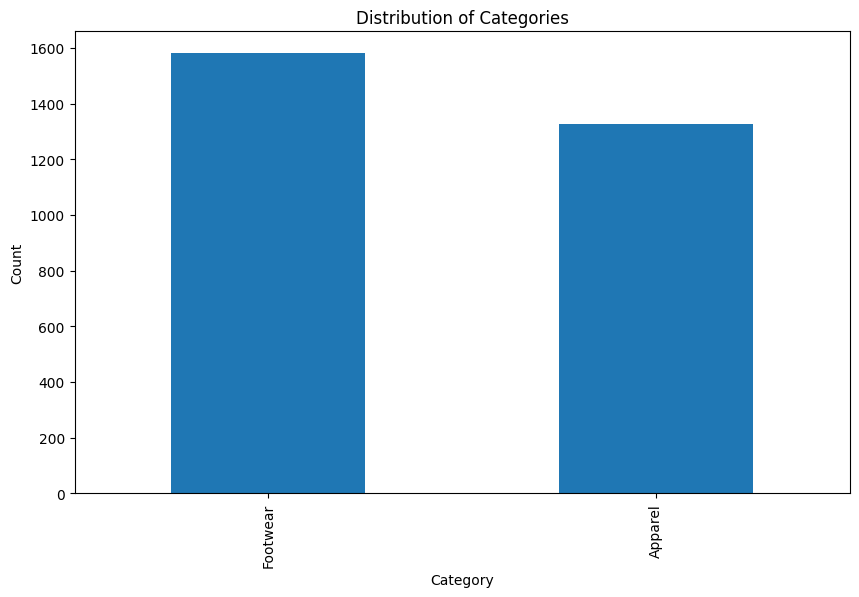

In [20]:
import matplotlib.pyplot as plt

# رسم نمودار میله‌ای برای توزیع مقادیر یک ستون
df['Category'].value_counts().plot(kind='bar', figsize=(10, 6))
plt.title("Distribution of Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()


In [21]:
print(df.describe())


          ProductId
count   2906.000000
mean   29229.495526
std    15527.390981
min     1636.000000
25%    15256.250000
50%    34016.500000
75%    40769.250000
max    59943.000000


In [23]:
print(df.columns)


Index(['ProductId', 'Gender', 'Category', 'SubCategory', 'ProductType',
       'Colour', 'Usage', 'ProductTitle', 'Image', 'ImageURL'],
      dtype='object')


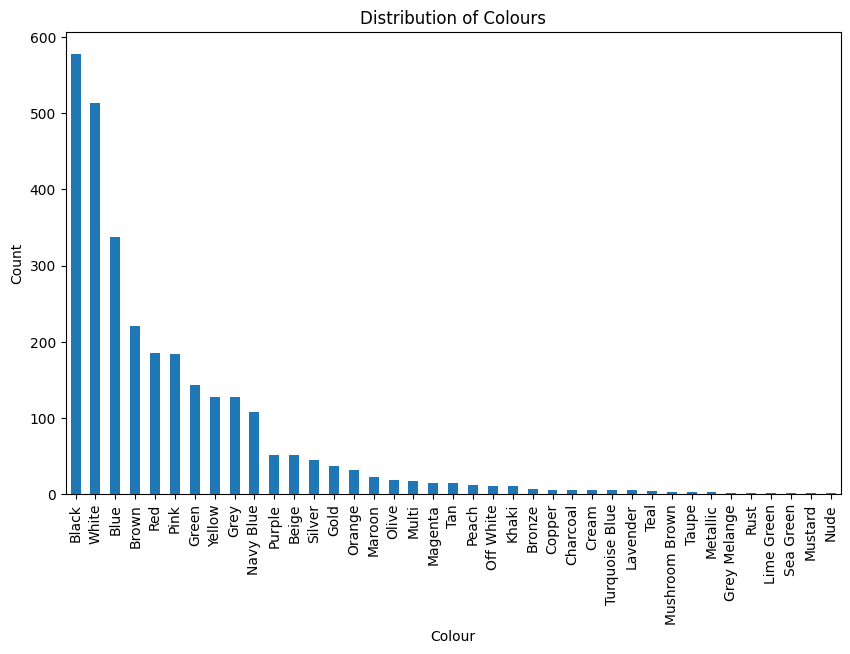

In [25]:
df['Colour'].value_counts().plot(kind='bar', figsize=(10, 6))
plt.title("Distribution of Colours")
plt.xlabel("Colour")
plt.ylabel("Count")
plt.show()
# بررسی توزیع دسته‌بندی‌ها

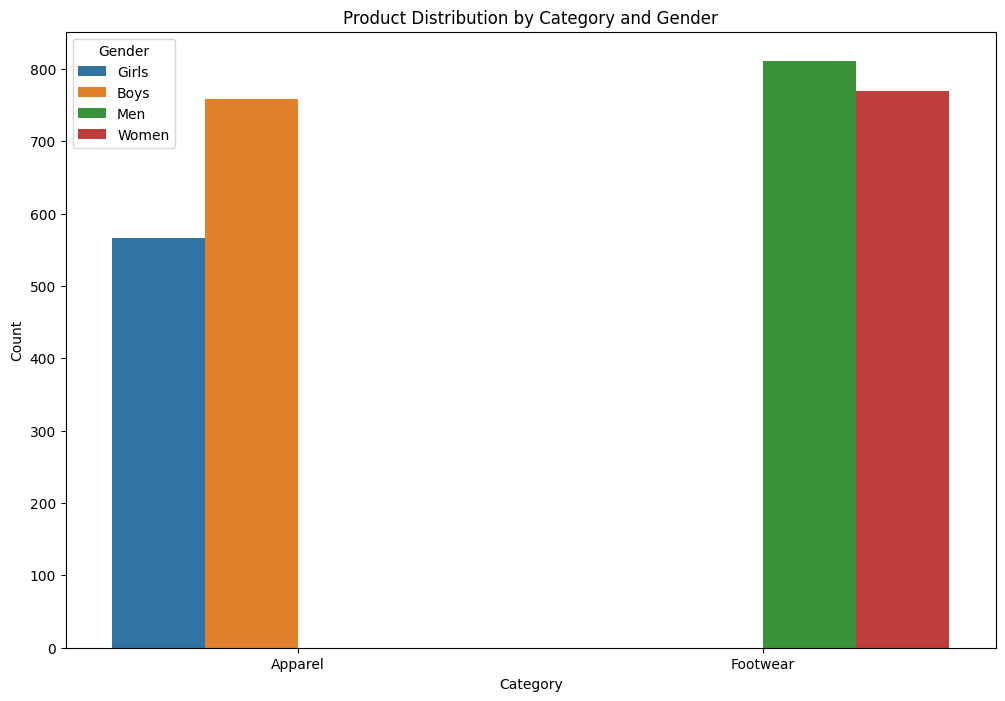

In [26]:
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='Category', hue='Gender')
plt.title("Product Distribution by Category and Gender")
plt.xlabel("Category")
plt.ylabel("Count")
plt.legend(title="Gender")
plt.show()
#این تحلیل به شما نشان می‌دهد که کدام دسته‌بندی‌ها برای هر جنسیت تقاضای بیشتری دارند.

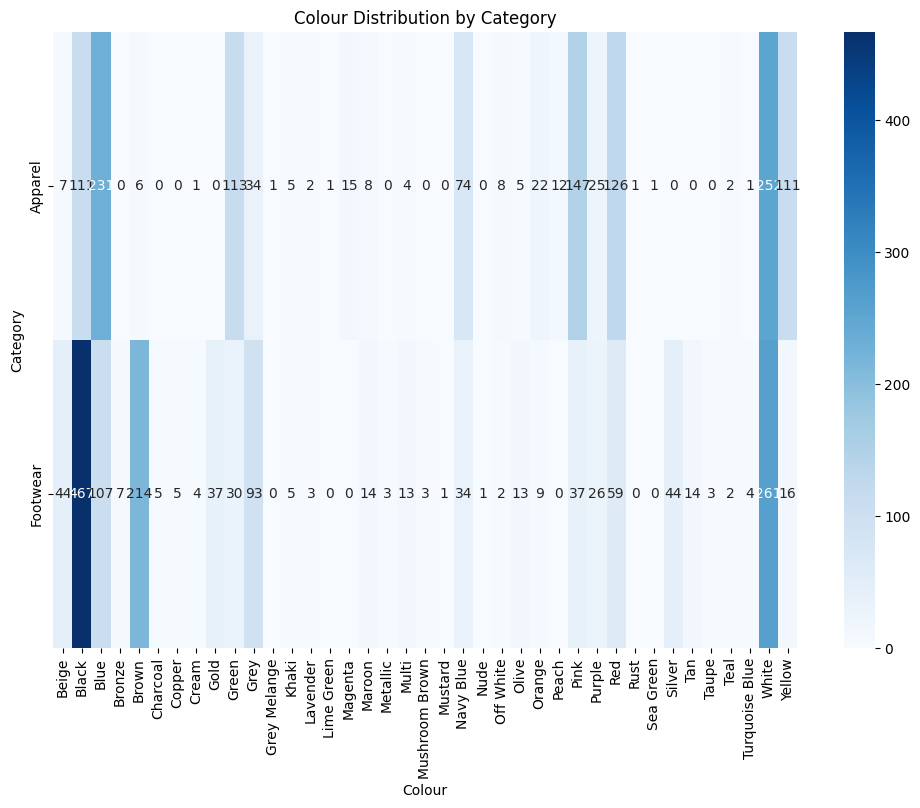

In [27]:
colour_category = pd.crosstab(df['Category'], df['Colour'])
plt.figure(figsize=(12, 8))
sns.heatmap(colour_category, annot=True, cmap='Blues', fmt="d")
plt.title("Colour Distribution by Category")
plt.xlabel("Colour")
plt.ylabel("Category")
plt.show()
#توزیع رنگ‌ها در دسته‌بندی‌های مختلف می‌تواند نشان دهد کدام رنگ‌ها در هر دسته‌بندی پرتقاضا هستند.



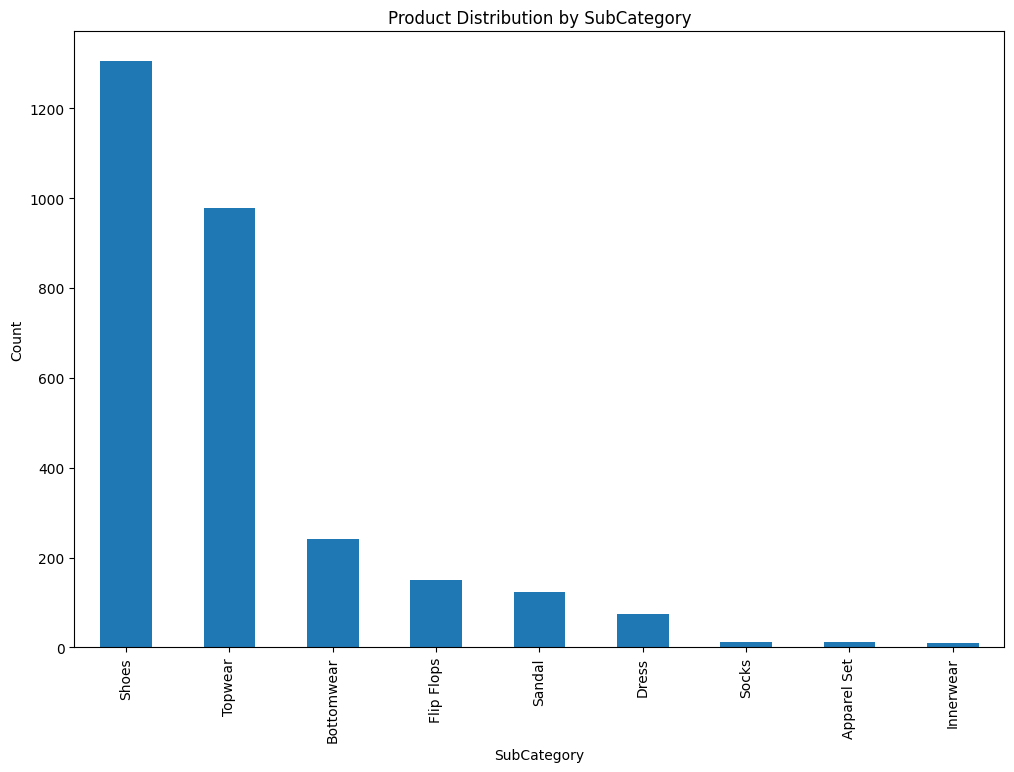

In [28]:
df['SubCategory'].value_counts().plot(kind='bar', figsize=(12, 8))
plt.title("Product Distribution by SubCategory")
plt.xlabel("SubCategory")
plt.ylabel("Count")
plt.show()


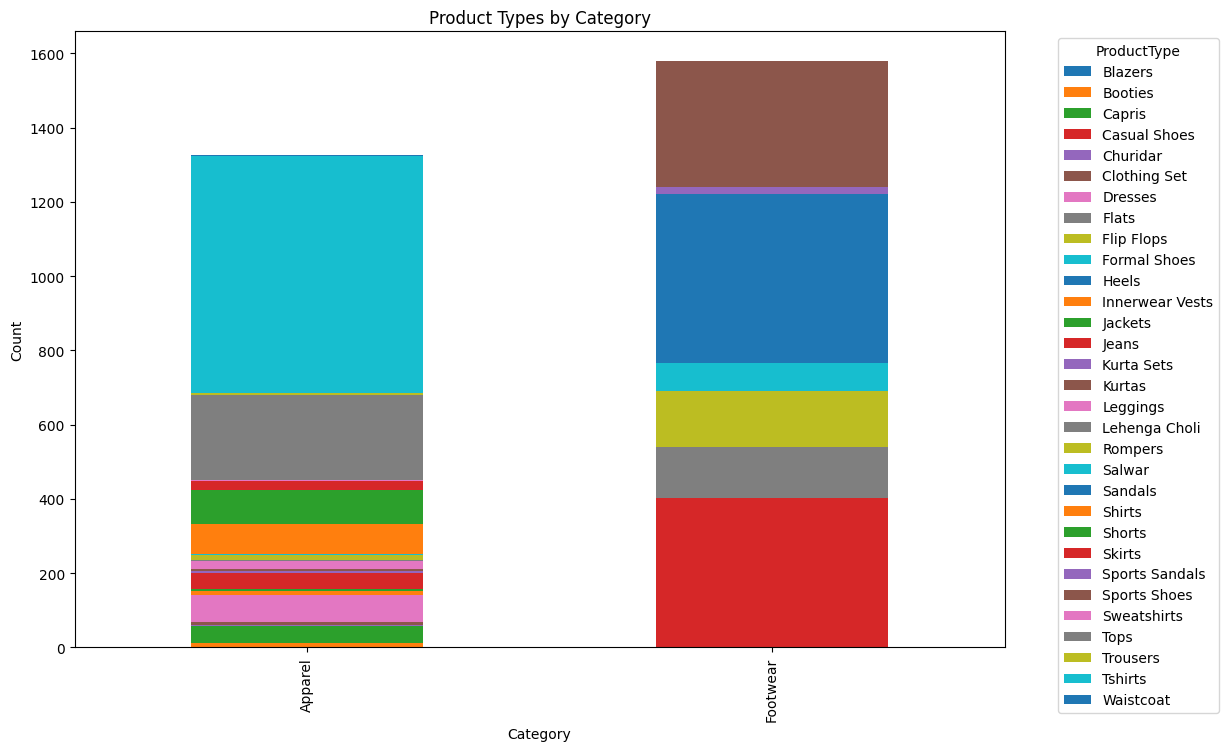

In [29]:
product_type_category = pd.crosstab(df['Category'], df['ProductType'])
product_type_category.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title("Product Types by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.legend(title="ProductType", bbox_to_anchor=(1.05, 1))
plt.show()
#از یک Pivot Table برای ترکیب چند ویژگی و پیدا کردن دسته‌بندی، رنگ و کاربردهای پرتقاضا استفاده کنید.

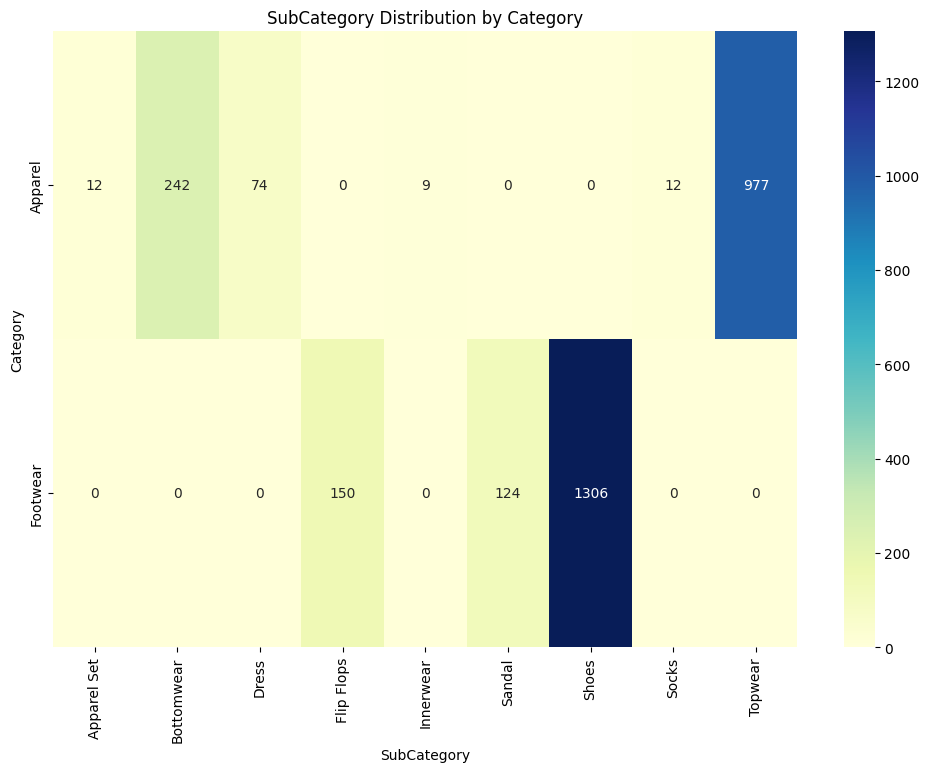

In [31]:
category_subcategory = pd.crosstab(df['Category'], df['SubCategory'])
plt.figure(figsize=(12, 8))
sns.heatmap(category_subcategory, annot=True, cmap='YlGnBu', fmt="d")
plt.title("SubCategory Distribution by Category")
plt.xlabel("SubCategory")
plt.ylabel("Category")
plt.show()
#شناسایی زیر‌دسته‌بندی‌هایی که در هر دسته‌بندی بیشترین حضور را دارند.





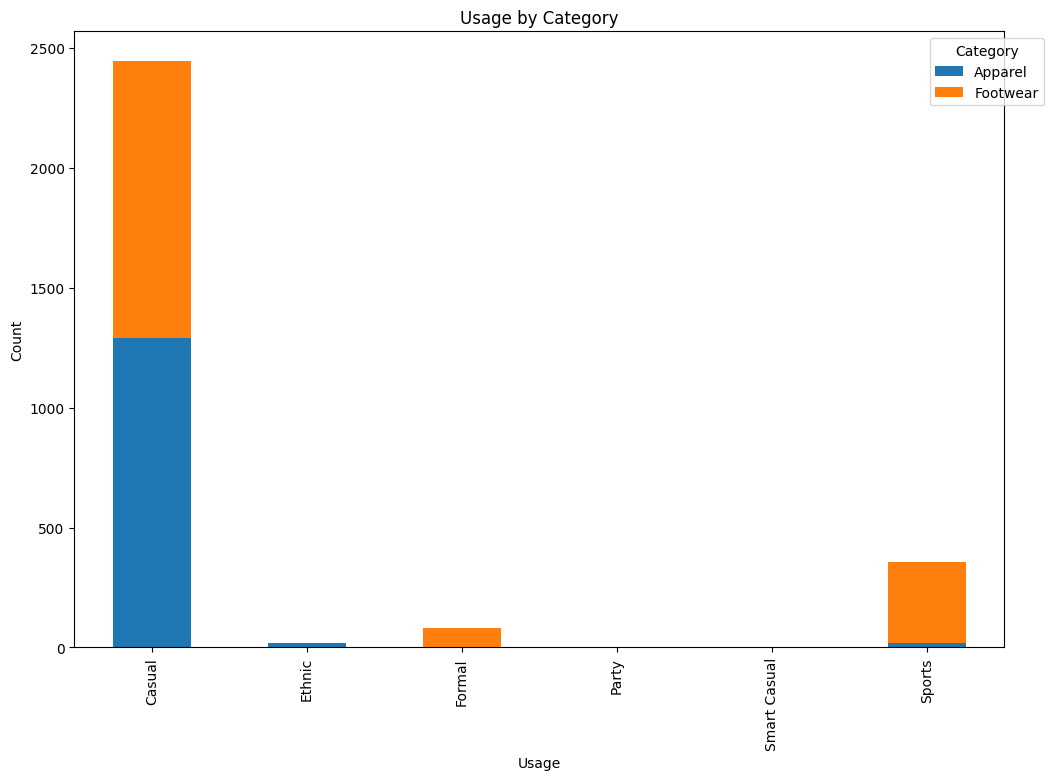

In [32]:
#بررسی اینکه چه کاربردهایی (رسمی، ورزشی و غیره) در دسته‌بندی‌های مختلف غالب هستند.
usage_category = pd.crosstab(df['Usage'], df['Category'])
usage_category.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title("Usage by Category")
plt.xlabel("Usage")
plt.ylabel("Count")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1))
plt.show()


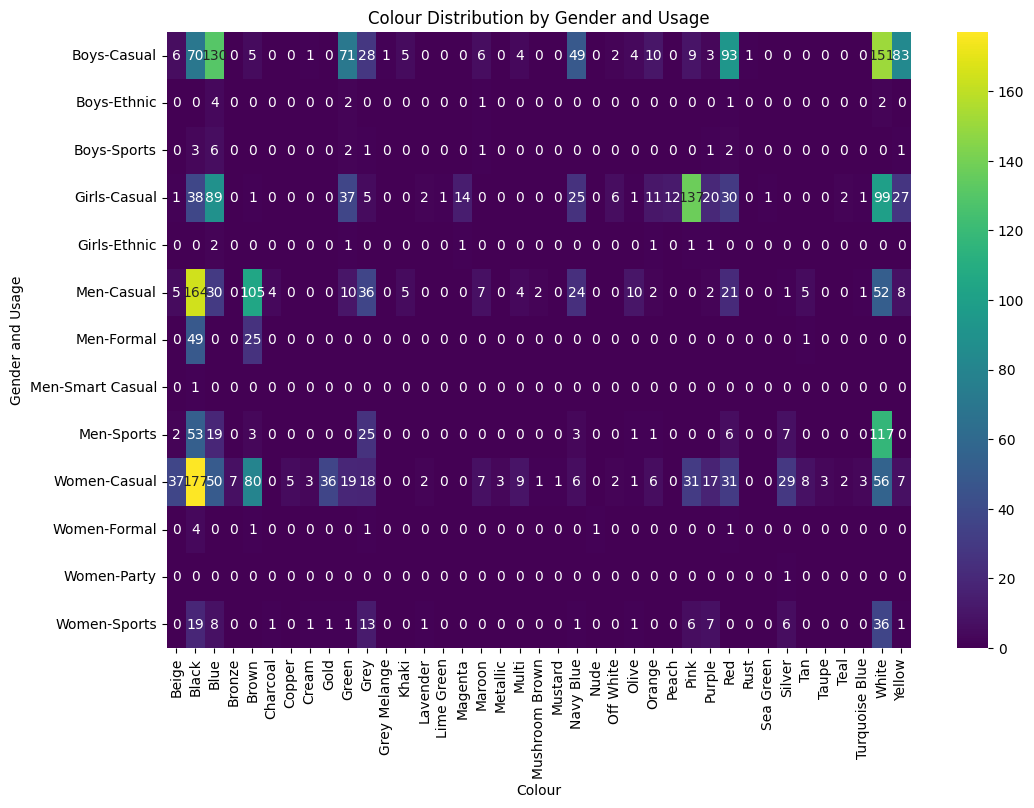

In [33]:
#شناسایی رنگ‌های محبوب برای هر جنسیت در کاربردهای مختلف.

plt.figure(figsize=(12, 8))
sns.heatmap(pd.crosstab([df['Gender'], df['Usage']], df['Colour']), annot=True, cmap="viridis", fmt="d")
plt.title("Colour Distribution by Gender and Usage")
plt.xlabel("Colour")
plt.ylabel("Gender and Usage")
plt.show()


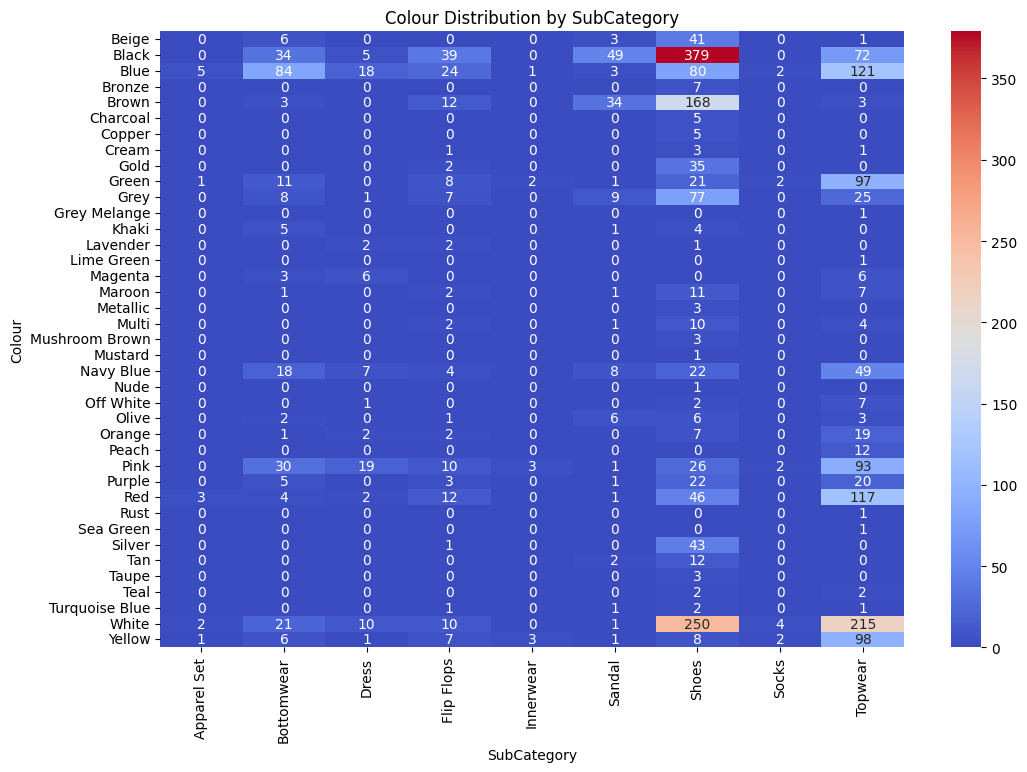

In [36]:
colour_subcategory = pd.crosstab(df['Colour'], df['SubCategory'])
plt.figure(figsize=(12, 8))
sns.heatmap(colour_subcategory, annot=True, cmap='coolwarm', fmt="d")
plt.title("Colour Distribution by SubCategory")
plt.xlabel("SubCategory")
plt.ylabel("Colour")
plt.show()
#شناسایی اینکه کدام ترکیب رنگ و زیر‌دسته‌بندی بیشترین تقاضا را دارد.

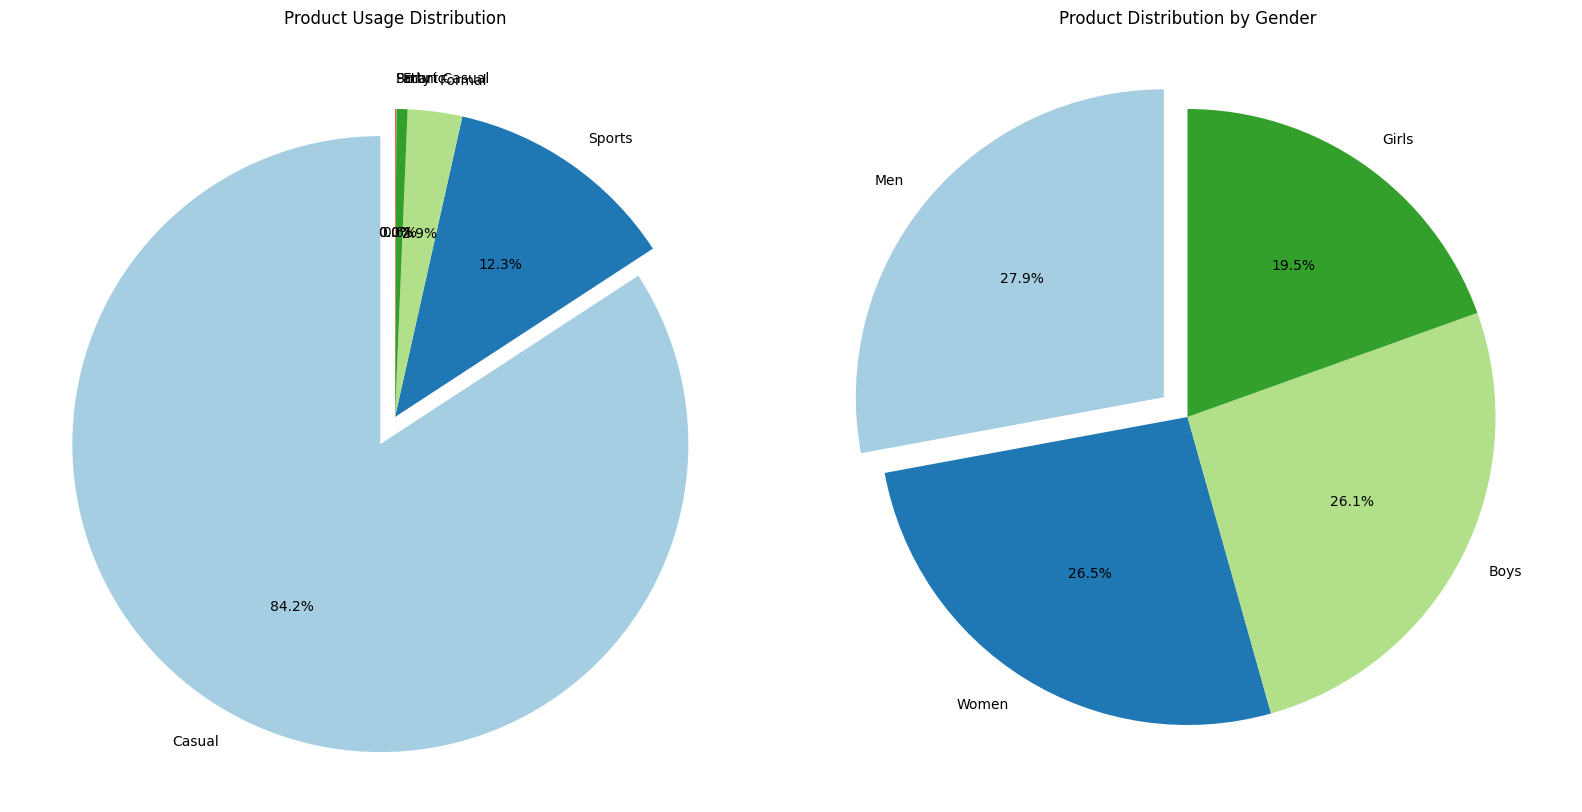

In [38]:
import matplotlib.pyplot as plt

# تنظیم اندازه شکل
fig, axes = plt.subplots(1, 2, figsize=(16, 8))  # 1 ردیف، 2 ستون

# نمودار دایره‌ای برای Usage
df['Usage'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[0],
    startangle=90,
    explode=[0.1] + [0] * (len(df['Usage'].value_counts()) - 1),
    colors=plt.cm.Paired.colors
)
axes[0].set_title("Product Usage Distribution")
axes[0].set_ylabel("")  # حذف عنوان محور Y

# نمودار دایره‌ای برای Gender
df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[1],
    startangle=90,
    explode=[0.1] + [0] * (len(df['Gender'].value_counts()) - 1),
    colors=plt.cm.Paired.colors
)
axes[1].set_title("Product Distribution by Gender")
axes[1].set_ylabel("")  # حذف عنوان محور Y

# نمایش نمودار
plt.tight_layout()
plt.show()


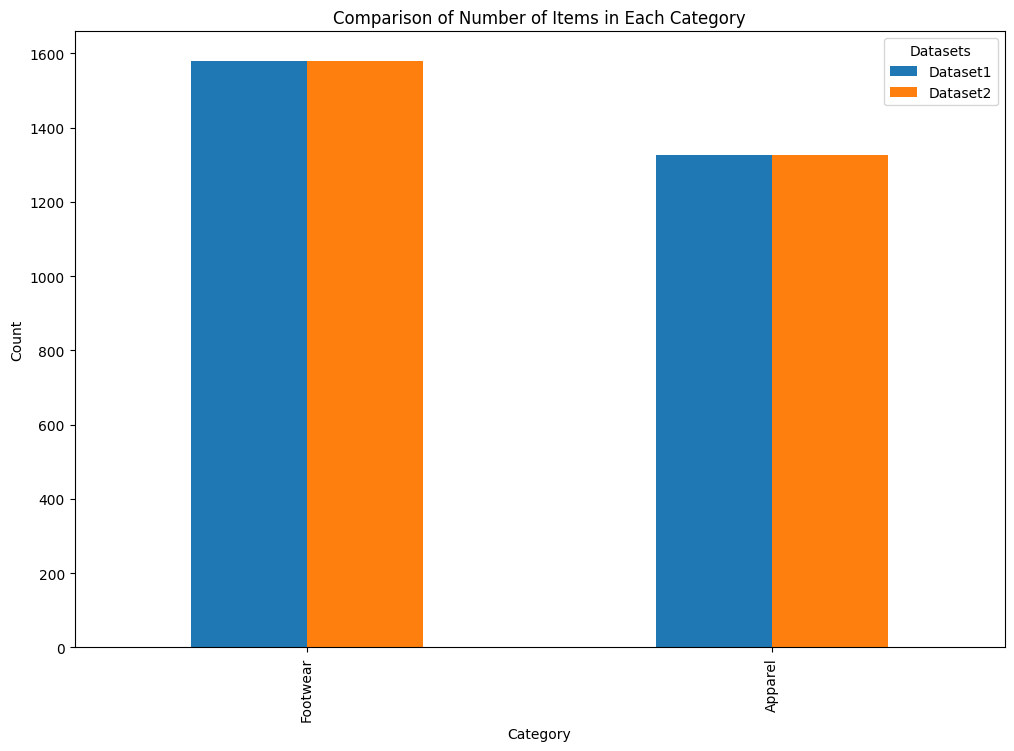

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

# داده‌های فرضی (داده‌های نمونه دوم را جایگزین کنید)
data1 = df['Category'].value_counts()  # داده اول
data2 = df['Category'].value_counts()  # داده دوم (به جای داده دیگر قرار دهید)

# ساخت DataFrame ترکیبی
combined_data = pd.DataFrame({'Dataset1': data1, 'Dataset2': data2})

# رسم نمودار
combined_data.plot(kind='bar', figsize=(12, 8))
plt.title("Comparison of Number of Items in Each Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.legend(title="Datasets")
plt.show()
